# Phụ lục C: Khảo sát quy mô dữ liệu dưới ngân sách cập nhật cố định

Ở [Phụ lục B](extension_b_objectives_and_repair.ipynb), kỹ thuật ghép cặp lại (re-pairing) đã cho thấy việc xáo trộn các ảnh cũ chỉ thay đổi cách thức tổ hợp chứ không bổ sung thêm thông tin khuôn mặt mới. Một câu hỏi chiến lược trong học máy là: Nếu ta thực sự mở rộng quy mô lượng ảnh huấn luyện độc lập thì độ chính xác của mô hình tăng trưởng theo quy luật nào?

Phụ lục này thiết kế một phép thử có kiểm soát chặt chẽ nhằm trả lời câu hỏi đó:
- Khảo sát mạng EfficientNet-B2 (đầu vào 288x288) trên 3 mức quy mô dữ liệu huấn luyện: 25%, 50% và 100% dữ liệu train.
- **Cố định ngân sách tối ưu hóa:** Mọi mức quy mô đều trải qua đúng 391 bước cập nhật trọng số gradient (terminal updates) và đánh giá ở checkpoint kết thúc.
- **Giữ nguyên tập kiểm định:** Tập kiểm định 3-fold OOF trên 800 cặp phát triển luôn được giữ nguyên vẹn 100% để đảm bảo thước đo đánh giá là hoàn toàn bất biến.

Ba cấu hình `data_25`, `data_50`, `data_100` giữ nguyên EfficientNet-B2 288px của phép thử này. Chúng không đổi theo mô hình đơn được chọn ở [Bài 05](05_backbone_and_selection.ipynb).


In [1]:
from pathlib import Path
import os
import sys

def find_task_root():
    explicit = os.environ.get('KMD_PROJECT_ROOT')
    if explicit:
        root = Path(explicit).expanduser().resolve()
        if (root / 'src/kmd').is_dir():
            return root
        raise FileNotFoundError('KMD_PROJECT_ROOT phải trỏ đến thư mục KeMaoDanh chứa src/kmd.')
    cwd = Path.cwd().resolve()
    for cand in [cwd, *cwd.parents]:
        if (cand / 'src/kmd').is_dir() and (cand / 'configs').is_dir():
            return cand.resolve()
        if (cand / 'KeMaoDanh/src/kmd').is_dir() and (cand / 'KeMaoDanh/configs').is_dir():
            return (cand / 'KeMaoDanh').resolve()
    raise FileNotFoundError("Không tìm thấy thư mục gốc KeMaoDanh chứa 'src/kmd' và 'configs'.")

TASK_ROOT = find_task_root()
if str(TASK_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(TASK_ROOT / 'src'))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from kmd.core import PACKAGE, read_csv, split_fold, metric
from kmd.presets import get_preset_config
from kmd.subsets import sample_train_subset, sample_smoke_train
from kmd.pipeline import prepare_development, start_session
from kmd.suite import run_data_amount_suite
from kmd.teaching import resolve_data_roots, show_pair_images

KMD_SMOKE = os.environ.get('KMD_SMOKE', '0') == '1'
KMD_RUN_ID = os.environ.get('KMD_RUN_ID', 'reasoning_pilot')
RUN_ID = f"{KMD_RUN_ID}_smoke" if (KMD_SMOKE and not KMD_RUN_ID.endswith('_smoke')) else KMD_RUN_ID

data_root, test_root = resolve_data_roots(TASK_ROOT)
if not data_root.is_dir() or not (data_root / 'pairs.csv').is_file():
    raise FileNotFoundError(
        f"Không tìm thấy thư mục dữ liệu huấn luyện tại '{data_root}'. "
        "Vui lòng thiết lập biến môi trường DATA_ROOT trỏ đến thư mục chứa 'pairs.csv' và 'images/'."
    )

dev_frame = prepare_development(data_root)
session_dir = start_session(dev_frame, data_root, run_id=RUN_ID)
print(f"Thư mục dự án: {TASK_ROOT}")
print(f"Phiên làm việc: {session_dir.relative_to(PACKAGE)}")
print(f"Tổng số mẫu phát triển: {len(dev_frame)} cặp")
print(f"Chế độ chạy thử (smoke test): {KMD_SMOKE}")

Thư mục dự án: /home/purin1410-desktop/kmd_full_v5_20260920/repo/KeMaoDanh
Phiên làm việc: artifacts/models/lesson_full_v5_20260920
Tổng số mẫu phát triển: 800 cặp
Chế độ chạy thử (smoke test): False


## 1. Thiết kế kiểm soát: Vì sao cố định số bước cập nhật thay vì số epoch?

Để so sánh tác động thuần túy của lượng dữ liệu, một thách thức phương pháp luận lớn là: làm thế nào để tách rời sự phong phú của dữ liệu khỏi số lần cập nhật gradient của bộ tối ưu hóa?

### Rủi ro nếu cố định số epoch:
Nếu chúng ta cho cả 3 mức dữ liệu (25%, 50%, 100%) chạy cùng 19 epoch, thì tập 100% dữ liệu sẽ thực hiện số bước cập nhật trọng số gradient (optimizer steps) xấp xỉ 4 lần tập 25% (còn phụ thuộc làm tròn batch cuối). Khi đó, nếu tập 100% đạt kết quả cao hơn, ta không thể biết chắc đó là nhờ dữ liệu đa dạng hơn hay chỉ đơn giản là do mạng được học nhiều bước gradient hơn.

### Giải pháp: Cố định chính xác 391 bước cập nhật (terminal update budget)
- Cả ba mức dữ liệu đều dừng lại ở đúng bước cập nhật thứ 391 (trong chế độ smoke test là 4 bước).
- Với mức 25% dữ liệu, tập train có ít mẫu hơn nên bộ nạp dữ liệu (data loader) sẽ quay vòng qua các mẫu nhiều lượt hơn (nhiều epoch hơn) để hoàn thành đủ 391 bước.
- Với mức 100% dữ liệu, mạng hoàn thành 391 bước với số epoch ít hơn.
- Như vậy, **số lần cập nhật trọng số bằng nhau**. Số lần lặp mỗi ảnh và batch cuối vẫn khác; ta đang so lượng dữ liệu dưới một ngân sách cập nhật chung.

Lưu ý về nguồn gốc tham số: Con số 391 bước cập nhật là ngân sách cố định trong preset của phép thử này, không phải là một số bước tối ưu đã được chứng minh lý thuyết. Đánh giá được thực hiện ở checkpoint cuối cùng (terminal checkpoint).

In [2]:
subset_specs = []
for fraction in (0.25, 0.50, 1.0):
    fold_counts = []
    for fold_idx in range(3):
        tr, _ = split_fold(dev_frame, fold=fold_idx)
        if KMD_SMOKE:
            sub = sample_smoke_train(tr, fold=fold_idx, max_pairs=64, fraction=fraction)
        else:
            sub = sample_train_subset(tr, fraction=fraction, fold=fold_idx)
        fold_counts.append(len(sub))
    subset_specs.append({
        'Tỷ lệ': f"{int(fraction * 100)}%",
        'Số cặp Fold 0': fold_counts[0],
        'Số cặp Fold 1': fold_counts[1],
        'Số cặp Fold 2': fold_counts[2],
        'Tổng lượt cặp qua 3 fold (có trùng)': sum(fold_counts),
        'Số bước updates': 4 if KMD_SMOKE else 391
    })

df_subsets = pd.DataFrame(subset_specs)
print("Quy mô số lượng mẫu huấn luyện ở từng fold và ngân sách cập nhật:")
print(df_subsets.to_string(index=False))
print("\nLưu ý: Tập kiểm định validation ở mỗi fold luôn giữ nguyên 100% (tổng 800 cặp OOF).")

Quy mô số lượng mẫu huấn luyện ở từng fold và ngân sách cập nhật:
Tỷ lệ  Số cặp Fold 0  Số cặp Fold 1  Số cặp Fold 2  Tổng lượt cặp qua 3 fold (có trùng)  Số bước updates
  25%            133            133            133                                  399              391
  50%            266            266            267                                  799              391
 100%            533            533            534                                 1600              391

Lưu ý: Tập kiểm định validation ở mỗi fold luôn giữ nguyên 100% (tổng 800 cặp OOF).


## 2. Huấn luyện bộ suite quy mô dữ liệu qua 3 fold OOF

Hàm `run_data_amount_suite` thực hiện huấn luyện cả 3 cấu hình:
- `data_25`: 25% dữ liệu huấn luyện, 391 updates.
- `data_50`: 50% dữ liệu huấn luyện, 391 updates.
- `data_100`: 100% dữ liệu huấn luyện, 391 updates.

Mỗi cấu hình chạy trên 3 fold và xuất dự đoán Out-Of-Fold hoàn chỉnh trên toàn bộ 800 cặp phát triển.

In [3]:
updates_budget = 4 if KMD_SMOKE else 391
print(f"Bắt đầu thực thi suite quy mô dữ liệu ({updates_budget} updates, 3 fold OOF)...")
table_data, preds_data = run_data_amount_suite(
    dev_frame, data_root, session_dir, smoke=KMD_SMOKE
)

frac_map = {'data_25': '25%', 'data_50': '50%', 'data_100': '100%'}
table_data['fraction'] = table_data['name'].map(frac_map)

display_cols = ['fraction', 'model', 'macro_f1', 'accuracy', 'log_loss', 'errors']
print("\nBảng so sánh hiệu năng theo quy mô dữ liệu huấn luyện (3-fold OOF trên 800 cặp):")
print(table_data[display_cols].to_string(index=False))

Bắt đầu thực thi suite quy mô dữ liệu (391 updates, 3 fold OOF)...



Bảng so sánh hiệu năng theo quy mô dữ liệu huấn luyện (3-fold OOF trên 800 cặp):
fraction    model  macro_f1  accuracy  log_loss  errors
     25%  data_25  0.876248   0.87625  0.803639      99
     50%  data_50  0.941249   0.94125  0.362025      47
    100% data_100  0.965000   0.96500  0.115961      28


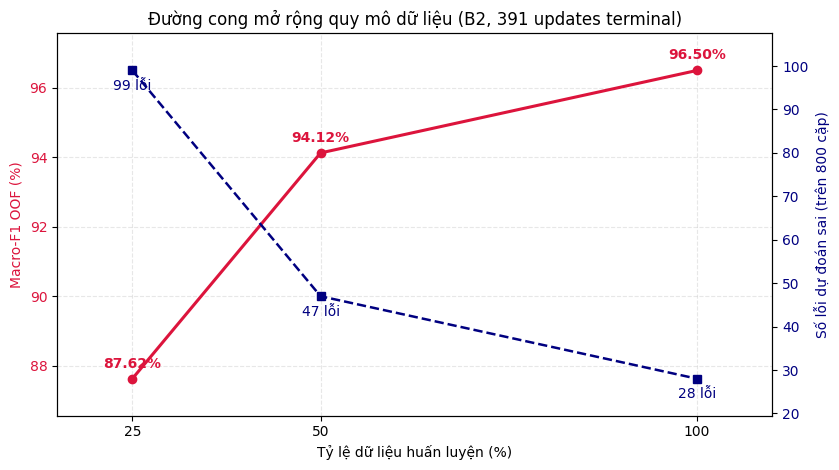

In [4]:
pct_numeric = [25, 50, 100]
f1_scores = (table_data['macro_f1'] * 100.0).to_numpy()
err_counts = table_data['errors'].to_numpy()

fig, ax1 = plt.subplots(figsize=(8.5, 4.8))

color_f1 = 'crimson'
ax1.set_xlabel("Tỷ lệ dữ liệu huấn luyện (%)")
ax1.set_ylabel("Macro-F1 OOF (%)", color=color_f1)
line1 = ax1.plot(pct_numeric, f1_scores, marker='o', color=color_f1, linewidth=2.2, label='Macro-F1 OOF (%)')
ax1.tick_params(axis='y', labelcolor=color_f1)

for x_val, y_val in zip(pct_numeric, f1_scores):
    ax1.annotate(f"{y_val:.2f}%", (x_val, y_val), textcoords="offset points", xytext=(0, 8), ha='center',
                 fontweight='bold', color=color_f1)

ax2 = ax1.twinx()
color_err = 'navy'
ax2.set_ylabel("Số lỗi dự đoán sai (trên 800 cặp)", color=color_err)
line2 = ax2.plot(pct_numeric, err_counts, marker='s', linestyle='--', color=color_err, linewidth=1.8, label='Số lỗi')
ax2.tick_params(axis='y', labelcolor=color_err)

for x_val, e_val in zip(pct_numeric, err_counts):
    ax2.annotate(f"{e_val} lỗi", (x_val, e_val), textcoords="offset points", xytext=(0, -14), ha='center',
                 color=color_err)

plt.title(f"Đường cong mở rộng quy mô dữ liệu (B2, {updates_budget} updates terminal)")
ax1.set_xticks(pct_numeric)
ax1.set_xlim(15, 110)
ax1.grid(True, linestyle='--', alpha=0.3)
ax1.margins(y=0.12)
ax2.margins(y=0.12)
fig.tight_layout()
plt.show()

### Đọc đường cong vừa tính

Đọc F1 và số lỗi tại từng mức trước khi nói về xu hướng. Hai khoảng 25%-50% và 50%-100% có độ dài khác nhau: nếu so độ dốc, chia mức tăng F1 cho số điểm phần trăm dữ liệu tăng thêm. Ba điểm trên một seed chưa cho phép suy ra một quy luật tăng trưởng.

Nếu thêm dữ liệu có lợi ở cả hai bước, đó là động lực thử thêm dữ liệu cùng nguồn. Nếu đường cong phẳng hoặc giảm, cần kiểm tra thành phần tập con, số lần lặp mẫu và ngân sách cập nhật trước khi kết luận đã đủ dữ liệu. Phép thử chưa chứng minh thu thập dữ liệu là phương án hiệu quả nhất so với mọi cải tiến khác.

In [5]:
fold_records = []
for name in ('data_25', 'data_50', 'data_100'):
    key = f"{name}_smoke" if KMD_SMOKE else name
    if key in preds_data:
        oof_df = preds_data[key]
        for fold_idx in range(3):
            val_sub = oof_df[oof_df['inner_fold'] == fold_idx]
            m_fold = metric(val_sub['fake_position'], val_sub['p'])
            fold_records.append({
                'Cấu hình': name,
                'Fold': fold_idx,
                'Số mẫu': len(val_sub),
                'Macro-F1 (%)': m_fold['macro_f1'] * 100.0,
                'Số lỗi': m_fold['errors']
            })

if fold_records:
    df_fold_var = pd.DataFrame(fold_records)
    print("Hiệu năng chi tiết trên từng Fold của 3 mức dữ liệu:")
    print(df_fold_var.to_string(index=False))
    
    print("\nĐộ lệch chuẩn Macro-F1 giữa 3 fold theo từng mức dữ liệu:")
    for name, grp in df_fold_var.groupby('Cấu hình'):
        std_f1 = grp['Macro-F1 (%)'].std(ddof=1)
        print(f"- {name}: Độ lệch chuẩn qua 3 fold = {std_f1:.2f} điểm phần trăm")

Hiệu năng chi tiết trên từng Fold của 3 mức dữ liệu:
Cấu hình  Fold  Số mẫu  Macro-F1 (%)  Số lỗi
 data_25     0     267     90.262036      26
 data_25     1     267     86.512124      36
 data_25     2     266     86.090029      37
 data_50     0     267     96.254629      10
 data_50     1     267     94.005388      16
 data_50     2     266     92.104259      21
data_100     0     267     97.003703       8
data_100     1     267     97.752525       6
data_100     2     266     94.735652      14

Độ lệch chuẩn Macro-F1 giữa 3 fold theo từng mức dữ liệu:
- data_100: Độ lệch chuẩn qua 3 fold = 1.57 điểm phần trăm
- data_25: Độ lệch chuẩn qua 3 fold = 2.30 điểm phần trăm
- data_50: Độ lệch chuẩn qua 3 fold = 2.08 điểm phần trăm


### Kiểm tra độ phân tán giữa các fold

Độ lệch chuẩn mô tả các fold của lượt chạy, không phải khoảng tin cậy. Các fold có tập train giao nhau và tập validation khác nhau. Xem mức 25% có dao động lớn hơn 100% thật không, rồi ghi kết quả; không mặc định xu hướng ấy phải xuất hiện.

## 3. Quyết định sau phép thử

Ghi mức dữ liệu tốt nhất trong ngân sách 391 updates và các đoạn có lợi ích nhỏ hoặc đảo chiều. Giữ số updates bằng nhau giúp giảm một nguồn gây nhiễu, nhưng không làm mọi điều kiện bằng nhau: tập nhỏ lặp ảnh nhiều hơn, batch cuối có thể khác và thời gian xử lý thực tế vẫn cần đo.

[Phụ lục D](extension_d_resize_augmentation.ipynb) giữ nguyên số ảnh, thử thay cách biến đổi ảnh lúc train. Như vậy ta phân biệt thêm dữ liệu với tăng cường từ dữ liệu có sẵn.